In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [37]:
def load_time_from_log(model_name, methods, log_dirs, categorys, win_sizes, stride_size):
    """Load time from CSV logs under multiple directories and merge into a result CSV."""
    all_rows = []

    for method, log_dir in zip(methods, log_dirs):
        if not os.path.isdir(log_dir):
            print(f"[WARN] Log dir not found, skip: {log_dir}")
            continue

        for category in categorys:
            for win_size in win_sizes:
                time_file = os.path.join(log_dir,
                    f"anomaly_win{win_size}s_stride{stride_size}pct_fps1.0",
                    category,
                    f"request_times_win{win_size}_stride{stride_size/100}.csv",)
                # print(f"Processing {time_file}")
                if not os.path.isfile(time_file):
                    print(f"[WARN] Time file not found, skip: {time_file}")
                    continue

                df_time = pd.read_csv(time_file)
                df_time = df_time[df_time["window_index"] != 0]
                # filter out window_index == 0 and end_frame-start_frame=win_size
                df_time = df_time[((df_time["end_frame"] - df_time["start_frame"]) == win_size)]
                for _, row in df_time.iterrows():
                    video_name = os.path.splitext(os.path.basename(row["video_path"]))[0]
                    all_rows.append({
                        "video_name": video_name,
                        "time_seconds": row["duration_seconds"],
                        "category": category,
                        "method": method,
                        "win_size": win_size,
                        "stride_size": stride_size,   
                    })

    if not all_rows:
        print("[WARN] No time records loaded.")
        return pd.DataFrame()

    df = pd.DataFrame(all_rows)
    df.sort_values(by=["method", "category", "video_name"], inplace=True)

    if os.path.isdir("../csv/") is False:
        os.makedirs("../csv/")
    if os.path.isdir(f"../csv/{model_name}/") is False:
        os.makedirs(f"../csv/{model_name}/")
    out_csv = f"../csv/{model_name}/various_wins_stride{stride_size}_time_results.csv"
    if os.path.exists(out_csv):
        df_existing = pd.read_csv(out_csv)
        df = pd.concat([df_existing, df], axis=0, ignore_index=True)

    # Remove duplicates and average time_seconds for the same (video, method, category, win/stride)
    df = (
        df.groupby(
            ["video_name", "method", "category", "win_size", "stride_size"],
            as_index=False
        )["time_seconds"].mean()
    )

    # Pivot: one column per method, values = time_seconds
    df = df.pivot_table(
        index=["video_name", "category", "win_size", "stride_size"],
        columns="method",
        values="time_seconds",
        aggfunc="first"
    ).reset_index()
    df.columns.name = None  # clean column index name

    # Optional: rename method columns if they exist
    rename_map = {}
    if "with_cacheblend" in df.columns:
        rename_map["with_cacheblend"] = "w_cacheblend"
    if "without_cacheblend" in df.columns:
        rename_map["without_cacheblend"] = "without_cacheblend"
    df.rename(columns=rename_map, inplace=True)
    # delete the video_name column
    df.drop(columns=["video_name"], inplace=True)
    # Group by category, win_size, stride_size and compute median times
    df = df.groupby(["category", "win_size", "stride_size"], as_index=False).mean()
    # add a new column ratio indicating time reduction ratio of w_cacheblend over without_cacheblend
    if "w_cacheblend" in df.columns and "without_cacheblend" in df.columns:
        df["speedup"] = (df["without_cacheblend"] - df["w_cacheblend"]) / df["without_cacheblend"]
    df.to_csv(out_csv, index=False)
    print(f"Loaded and saved {len(df)} records to {out_csv}")
    return df

In [38]:
def plot_latency_speedup_with_various_wins(csv_path, out_pdf):
    df = pd.read_csv(csv_path)
    df['speedup'] = (df['without_cacheblend'] - df['w_cacheblend']) / df['without_cacheblend']
    df.to_csv(csv_path, index=False)
    fig = plt.figure(figsize=(3, 2), dpi=150)
    ax = fig.add_subplot(1, 1, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.plot(df["win_size"], df["speedup"]*100, marker='o', color=plt.cm.tab20b(0), linestyle='-.')
    x_major_locator = plt.MultipleLocator(10)
    y_major_locator = plt.MultipleLocator(5)
    ax.xaxis.set_major_locator(x_major_locator)
    ax.yaxis.set_major_locator(y_major_locator)
    ax.set_ylim(0, max(df["speedup"]*100)*1.1)
    ax.set_xlabel("Window Size (s)")
    ax.set_xticklabels([int(x) for x in ax.get_xticks()], rotation=15)
    ax.set_ylabel("Speedup (%)")
    ax.grid(axis='y', visible=True, linestyle='--', alpha=0.5)
    plt.tight_layout(pad=.1)
    plt.savefig(out_pdf, bbox_inches='tight')
    print(f"Saved figure to {out_pdf}")

In [39]:
def load_accuracy_from_log(method, log_dir, category, win_size, stride_size):
    """Load accuracy labels from JSON logs under one directory."""
    df = pd.DataFrame()
    if not os.path.isdir(log_dir):
        return df

    for acc_file in os.listdir(log_dir):
        if not acc_file.endswith(".json"):
            continue
        acc_path = os.path.join(log_dir, acc_file)
        with open(acc_path, "r") as f:
            json_data = json.load(f)

        # Extract content from OpenAI-style response["choices"][0]["message"]["content"]
        resp = json_data.get("response", {})

        content = resp["choices"][0]["delta"]["content"]
        if not content:
            continue
        content = content.strip()

        # Parse label from content, expected "Yes" or "No"
        if "Yes" in content:
            est = "Yes"
        elif "No" in content:
            est = "No"
        else:
            continue  # skip invalid label

        # Parse standard video name from filename
        video_name = os.path.splitext(os.path.basename(acc_path))[0]
        video_name_splits = video_name.split("_")
        if len(video_name_splits) >= 4:
            video_name = "_".join(video_name_splits[1:4])

        # Update dataframe; once a video is marked "Yes", keep it
        if video_name in df.index:
            if est == "Yes":
                df.loc[video_name, "est"] = "Yes"
        else:
            df.loc[video_name, "est"] = est

        df.loc[video_name, "category"] = category
        df.loc[video_name, "method"] = method
        df.loc[video_name, "win_size"] = win_size
        df.loc[video_name, "stride_size"] = stride_size

    if not df.empty:
        df = df.reset_index().rename(columns={"index": "video_name"})
    return df

def parse_accuracy_log(model_name, with_cacheblend_dir, without_cacheblend_dir, win_sizes, stride_sizes, fps, categorys):
    """Parse accuracy logs for all configurations and write to a CSV file."""
    results = []
    for win_size in win_sizes:
        for stride_size in stride_sizes:
            for category in categorys:
                # with CacheBlend
                acc_dir_with = os.path.join(with_cacheblend_dir, f"anomaly_win{win_size}s_stride{stride_size}pct_fps{fps}", category)
                print(f"Processing {acc_dir_with}")
                df_with = load_accuracy_from_log("w_cacheblend", acc_dir_with, category, win_size, stride_size)
                print(df_with.head(10))
                if not df_with.empty:
                    results.append(df_with)
                # without CacheBlend
                acc_dir_without = os.path.join(without_cacheblend_dir, f"anomaly_win{win_size}s_stride{stride_size}pct_fps{fps}", category)
                print(f"Processing {acc_dir_without}")
                df_without = load_accuracy_from_log("without_cacheblend", acc_dir_without, category, win_size, stride_size)
                print(df_without.head(10))
                if not df_without.empty:
                    results.append(df_without)

    if not results:
        print("No accuracy logs found, CSV not generated.")
        return

    results_df = pd.concat(results, axis=0, ignore_index=True)
    results_df = results_df.sort_values(by=["method", "category", "video_name"])
    print(f"Loaded {len(results_df)} accuracy records.")
    results_df = results_df.pivot_table(index=["win_size", "stride_size", "category", "video_name"],
                                        columns="method",
                                        values="est",
                                        aggfunc='first').reset_index()
    results_df["ground_truth"] = "Yes"
    if not os.path.exists(f"../csv/{model_name}"):
        os.makedirs(f"../csv/{model_name}")
    results_df.to_csv(f"../csv/{model_name}/win{win_size}_various_strides_accuracy_results.csv", index=False)
    return results_df

In [40]:
def parse_accuracy_latency_speedup(model_name, log_dir, categorys, win_size, stride_size, fps, recompute_ratios):
    latency_records = []
    accuracy_records = []

    for recompute_ratio in recompute_ratios:
        for category in categorys:
            subdir = os.path.join(
                log_dir,
                f"recompute_{recompute_ratio}",
                f"anomaly_win{win_size}s_stride{stride_size}pct_fps{fps}",
                category,
            )

            latency_file = os.path.join(
                subdir,
                f"request_times_win{win_size}_stride{stride_size/100}.csv"
            )

            if not os.path.isfile(latency_file):
                print(f"[WARN] Latency file not found, skip: {latency_file}")
            else:
                df_latency = pd.read_csv(latency_file)
                # Only filter latency with valid window index and full window length
                df_latency = df_latency[(df_latency["window_index"] != 0)]
                df_latency = df_latency[((df_latency["end_frame"] - df_latency["start_frame"]) == win_size)]
                for _, row in df_latency.iterrows():
                    # Prefer output_path so the identifier matches the accuracy JSON file names
                    raw_name = row.get("output_path") or row.get("video_path")
                    base_name = os.path.splitext(os.path.basename(raw_name))[0]
                    name_parts = base_name.split("_")
                    if len(name_parts) >= 4:
                        video_name = name_parts[1]
                    else:
                        video_name = base_name

                    latency_records.append({
                        "video_name": video_name,
                        "time_seconds": row["duration_seconds"],
                        "category": category,
                        "win_size": win_size,
                        "stride_size": stride_size,
                        "recompute_ratio": recompute_ratio,
                    })

            accuracy_dir = subdir
            if not os.path.isdir(accuracy_dir):
                print(f"[WARN] Accuracy dir not found, skip: {accuracy_dir}")
                continue

            json_files = [f for f in os.listdir(accuracy_dir) if f.endswith(".json")]
            if not json_files:
                print(f"[WARN] No accuracy json files found in {accuracy_dir}")

            for json_file in json_files:
                json_path = os.path.join(accuracy_dir, json_file)
                with open(json_path, "r") as f:
                    json_data = json.load(f)

                resp = json_data.get("response", {})
                choices = resp.get("choices", []) or []
                if not choices:
                    continue
                delta = choices[0].get("delta", {}) or {}
                content = delta.get("content") or choices[0].get("message", {}).get("content")
                if not content:
                    continue

                content_str = content.strip()
                content_upper = content_str.upper()
                if content_upper.startswith("YES"):
                    est = "Yes"
                elif content_upper.startswith("NO"):
                    est = "No"
                else:
                    continue

                video_name = os.path.splitext(os.path.basename(json_file))[0]
                is_normal = "normal" in video_name.lower()
                video_name_splits = video_name.split("_")
                if len(video_name_splits) >= 4:
                    video_name = video_name_splits[1]
                accuracy_records.append({
                    "video_name": video_name,
                    "category": category,
                    "is_normal": is_normal,
                    "est": est,
                    "recompute_ratio": recompute_ratio,
                    "ground_truth": "No" if is_normal else "Yes",
                })

    if not latency_records or not accuracy_records:
        print("[WARN] No latency or accuracy records found.")
        return

    df_latency_all = pd.DataFrame(latency_records)
    df_accuracy_all = pd.DataFrame(accuracy_records)

    # Aggregate latency per video/category/ratio (mean across windows)
    df_latency_agg = df_latency_all.groupby(
        ["video_name", "category", "recompute_ratio"],
        as_index=False
    )["time_seconds"].mean()

    # Aggregate accuracy per video/category/ratio: any window Yes => Yes; else No
    acc_rows = []
    for (video_name, category, ratio), group in df_accuracy_all.groupby(
        ["video_name", "category", "recompute_ratio"]
    ):
        final_est = "Yes" if (group["est"] == "Yes").any() else "No"
        acc_rows.append({
            "video_name": video_name,
            "category": category,
            "recompute_ratio": ratio,
            "est": final_est,
        })
    df_accuracy_agg = pd.DataFrame(acc_rows)

    # Merge for raw output (keep accuracy rows even if latency missing)
    df_merged = df_accuracy_agg.merge(
        df_accuracy_all[["video_name", "category", "recompute_ratio", "ground_truth"]].drop_duplicates(),
        on=["video_name", "category", "recompute_ratio"],
        how="left"
    )
    if df_merged.empty:
        print("[WARN] No merged records after combining latency and accuracy.")
        return


    # Prepare latency summary by ratio/category
    latency_summary = df_latency_agg.groupby(
        ["recompute_ratio", "category"], as_index=False
    )["time_seconds"].mean()
    summary_rows = []
    for (ratio, category), group in df_merged.groupby(["recompute_ratio", "category"]):
        tp = ((group["est"] == "Yes") & (group["ground_truth"] == "Yes")).sum()
        fp = ((group["est"] == "Yes") & (group["ground_truth"] == "No")).sum()
        fn = ((group["est"] == "No") & (group["ground_truth"] == "Yes")).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        accuracy = (group["est"] == group["ground_truth"]).mean()

        latency_row = latency_summary[
            (latency_summary["recompute_ratio"] == ratio) & (latency_summary["category"] == category)
        ]
        latency_val = latency_row["time_seconds"].iloc[0] if not latency_row.empty else float("nan")

        summary_rows.append({
            "category": category,
            "win_size": win_size,
            "stride_size": stride_size,
            "recompute_ratio": ratio,
            "latency_seconds": latency_val,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1_score,
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df.sort_values(by=["category", "recompute_ratio"], inplace=True)

    out_dir = os.path.join("..", "csv", model_name)
    os.makedirs(out_dir, exist_ok=True)

    raw_csv = os.path.join(out_dir, f"win{win_size}_stride{stride_size}_latency_accuracy_recompute_raw.csv")
    summary_csv = os.path.join(out_dir, f"win{win_size}_stride{stride_size}_latency_accuracy_by_recompute.csv")
    df_merged.to_csv(raw_csv, index=False)
    summary_df.to_csv(summary_csv, index=False)

    print(f"Saved merged latency and accuracy results to {raw_csv}")
    print(f"Saved summary metrics to {summary_csv}")
    return summary_df


In [41]:
# plotting functions can be added here if needed
def plot_accuracy_latency_with_various_recompute_ratios(csv_path, out_pdf):
    df = pd.read_csv(csv_path)
    if df.empty:
        print(f"[WARN] No data found in {csv_path}")
        return

    df_plot = (
        df.groupby("recompute_ratio", as_index=False)
        .agg({"latency_seconds": "mean", "f1_score": "mean"})
        .sort_values("recompute_ratio")
    )
    df_plot['reuse_ratio'] = 100 - df_plot['recompute_ratio'].astype(float) * 100
    df_plot['speedup'] = (df_plot['latency_seconds'].max() - df_plot['latency_seconds']) / df_plot['latency_seconds'].max()
    df_plot.sort_values("reuse_ratio", inplace=True)
    print(df_plot)

    fig, ax_latency = plt.subplots(figsize=(3, 2), dpi=150)
    color_latency = plt.cm.tab20b(0)
    color_f1 = plt.cm.tab20b(4)

    ax_latency.plot(
        df_plot["reuse_ratio"],
        df_plot["speedup"]*100,
        marker="o",
        linestyle="-",
        color=color_latency,
        label="Latency (s)",
    )
    ax_latency.set_xlabel("Reuse Ratio (%)")
    ax_latency.set_ylabel("Speedup (%)", color=color_latency)
    ax_latency.tick_params(axis="y", labelcolor=color_latency)
    ax_latency.grid(axis="y", linestyle="--", alpha=0.4)

    ax_f1 = ax_latency.twinx()
    ax_f1.plot(
        df_plot["reuse_ratio"],
        df_plot["f1_score"],
        marker="s",
        linestyle="--",
        color=color_f1,
        label="F1-score",
    )
    ax_f1.set_ylabel("F1-score", color=color_f1)
    ax_f1.tick_params(axis="y", labelcolor=color_f1)
    ax_f1.set_ylim(0, 1)

    # combine legends from both axes
    lines_labels = [ax_latency.get_legend_handles_labels(), ax_f1.get_legend_handles_labels()]
    lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
    # ax_f1.legend(lines, labels, loc="upper right", frameon=False)
    plt.tight_layout()
    plt.savefig(out_pdf, bbox_inches="tight")
    print(f"Saved plot to {out_pdf}")


Saved merged latency and accuracy results to ../csv/Qwen3-VL-8B-Instruct/win120_stride20_latency_accuracy_recompute_raw.csv
Saved summary metrics to ../csv/Qwen3-VL-8B-Instruct/win120_stride20_latency_accuracy_by_recompute.csv
   recompute_ratio  latency_seconds  f1_score  reuse_ratio   speedup
9              1.0         1.651212  0.666667          0.0  0.000000
8              0.9         1.617741  0.545455         10.0  0.020271
7              0.8         1.609805  0.545455         20.0  0.025077
6              0.7         1.502741  0.166667         30.0  0.089917
5              0.6         1.438055  0.307692         40.0  0.129091
4              0.5         1.368481  0.600000         50.0  0.171227
3              0.4         1.337882  0.727273         60.0  0.189758
2              0.3         1.296187  0.833333         70.0  0.215009
1              0.2         1.355454  0.727273         80.0  0.179116
0              0.1         1.291618  0.833333         90.0  0.217776
Saved plot to 

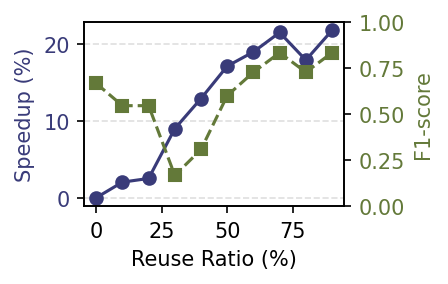

In [42]:
model_name = "Qwen3-VL-8B-Instruct"
methods = ["with_cacheblend", "without_cacheblend"]
log_dirs = [
    f"../logs/{model_name}/various_windows", f"../logs_baselines/{model_name}/various_windows",
]
categorys = ["vandalism"]
win_sizes = [60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
stride_size = 20
# df_results = load_time_from_log(model_name, methods, log_dirs, categorys, win_sizes, stride_size)
# plot_latency_speedup_with_various_wins(
#     f"../csv/{model_name}/various_wins_stride{stride_size}_time_results_final.csv",
#     f"../pdfs/{model_name}_latency_speedup_various_wins.pdf"
# )
# Parse accuracy logs
win_size, stride_size = 120, 20
parse_accuracy_latency_speedup(
    model_name,
    f"../logs/{model_name}/various_recompute_ratios/",
    categorys,
    win_size,
    stride_size,
    fps=1.0,
    recompute_ratios=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
)
plot_accuracy_latency_with_various_recompute_ratios(
    f"../csv/{model_name}/win{win_size}_stride{stride_size}_latency_accuracy_by_recompute.csv",
    f"../pdfs/{model_name}_win{win_size}_stride{stride_size}_accuracy_latency_various_recompute_ratios.pdf"
)